In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,accuracy_score

this is a dataset on ai impact on jobs and layoff risk across industries .
Objective is to analyze the relationship between ai adoptions , task automation , workforce characterstics and employment risk.
building classifications model to predict layoff and risk 

In [2]:
df=pd.read_csv("D:/yash - downloads/dataset/ai-impact-jobs-layoff-risk-dataset.csv")
df.head()

,Age,Education_Level,Years_of_Experience,Industry,Job_Role,Company_Size,Job_Level,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,AI_Adoption_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours,Layoff_Risk
0,59,Master's,6,Finance,Accountant,Medium,Entry,84,21,94,Medium,5,7,40,26,High
1,44,Master's,14,Manufacturing,Production Supervisor,Small,Entry,30,84,68,Low,2,2,14,9,Low
2,36,Bachelor's,7,Retail,Store Manager,Medium,Senior,12,86,71,Low,0,1,6,3,Low
3,27,Bachelor's,6,Finance,Auditor,Large,Entry,90,18,21,Medium,3,10,67,26,High
4,49,High School,12,Finance,Auditor,Small,Entry,49,52,72,Medium,5,13,26,19,Medium


In [3]:
df.shape

(20000, 16)

In [4]:
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Age                         20000 non-null  int64
 1   Education_Level             20000 non-null  str  
 2   Years_of_Experience         20000 non-null  int64
 3   Industry                    20000 non-null  str  
 4   Job_Role                    20000 non-null  str  
 5   Company_Size                20000 non-null  str  
 6   Job_Level                   20000 non-null  str  
 7   Routine_Task_Percentage     20000 non-null  int64
 8   Creativity_Requirement      20000 non-null  int64
 9   Human_Interaction_Level     20000 non-null  int64
 10  AI_Adoption_Level           20000 non-null  str  
 11  Number_of_AI_Tools_Used     20000 non-null  int64
 12  AI_Usage_Hours_Per_Week     20000 non-null  int64
 13  Tasks_Automated_Percentage  20000 non-null  int64
 14  AI_Training_Hours

,Age,Years_of_Experience,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.00000,20000.000000
mean,40.361500,7.265500,51.885500,47.786700,60.055000,2.460350,6.77395,37.22895,12.621400
std,11.526333,4.720606,24.437808,26.100482,22.267801,2.097486,6.08637,19.99512,13.552647
min,21.000000,0.000000,10.000000,0.000000,20.000000,0.000000,0.00000,4.00000,0.000000
25%,30.000000,4.000000,31.000000,27.000000,41.000000,1.000000,2.00000,21.00000,4.000000
50%,40.000000,7.000000,52.000000,48.000000,62.000000,2.000000,5.00000,35.00000,8.000000
75%,50.000000,11.000000,73.000000,69.000000,79.000000,4.000000,10.00000,51.00000,18.000000
max,60.000000,32.000000,94.000000,100.000000,99.000000,10.000000,30.00000,93.00000,79.000000


In [5]:
df.isnull().sum()

Age                           0
Education_Level               0
Years_of_Experience           0
Industry                      0
Job_Role                      0
Company_Size                  0
Job_Level                     0
Routine_Task_Percentage       0
Creativity_Requirement        0
Human_Interaction_Level       0
AI_Adoption_Level             0
Number_of_AI_Tools_Used       0
AI_Usage_Hours_Per_Week       0
Tasks_Automated_Percentage    0
AI_Training_Hours             0
Layoff_Risk                   0
dtype: int64

In [6]:
corr_matrix=df.corr(numeric_only=True) # this will work as it drops columns have non numeric data
print(corr_matrix)


                                 Age  Years_of_Experience  \
Age                         1.000000             0.381019   
Years_of_Experience         0.381019             1.000000   
Routine_Task_Percentage     0.000242            -0.003817   
Creativity_Requirement      0.000530             0.004944   
Human_Interaction_Level     0.002161             0.014545   
Number_of_AI_Tools_Used     0.003540            -0.003431   
AI_Usage_Hours_Per_Week     0.004635            -0.003771   
Tasks_Automated_Percentage -0.000609            -0.004052   
AI_Training_Hours          -0.001468            -0.002974   

                            Routine_Task_Percentage  Creativity_Requirement  \
Age                                        0.000242                0.000530   
Years_of_Experience                       -0.003817                0.004944   
Routine_Task_Percentage                    1.000000               -0.927758   
Creativity_Requirement                    -0.927758                1.0000

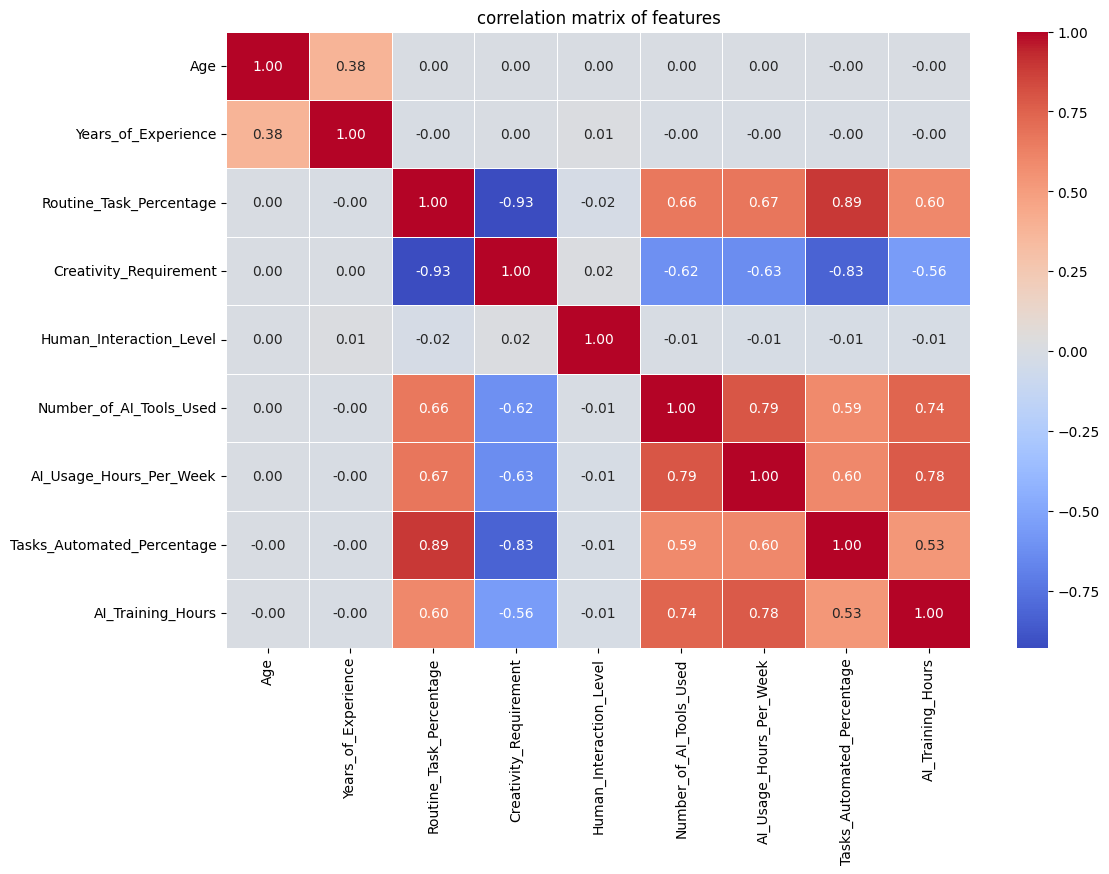

In [7]:
#ploting heatmap ( visulisatio of correlations matrix )
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('correlation matrix of features')
plt.show()


In [8]:
#droping these columns as they likely may cause overfiting because of there high correlations 
features_to_drop=['Creativity_Requirement','Tasks_Automated_Percentage']
df=df.drop(columns=features_to_drop,errors='ignore')


In [9]:
updated=df.drop(columns='Layoff_Risk')
#before spliting and asigning layoff column to y we need to change string int int 
target_mapping={'Low':0,'Medium':1,'High':2}
df['Layoff_Risk']=df['Layoff_Risk'].map(target_mapping)
y=df['Layoff_Risk']

In [10]:
#encodeling the features have dtype string 
df_encoded=pd.get_dummies(updated,drop_first=True)
df_encoded.head()
print(df_encoded.columns.tolist())
X=df_encoded

['Age', 'Years_of_Experience', 'Routine_Task_Percentage', 'Human_Interaction_Level', 'Number_of_AI_Tools_Used', 'AI_Usage_Hours_Per_Week', 'AI_Training_Hours', 'Education_Level_High School', "Education_Level_Master's", 'Education_Level_PhD', 'Industry_Finance', 'Industry_Healthcare', 'Industry_IT', 'Industry_Logistics', 'Industry_Manufacturing', 'Industry_Retail', 'Industry_Telecom', 'Job_Role_Accountant', 'Job_Role_Auditor', 'Job_Role_Data Analyst', 'Job_Role_Dispatcher', 'Job_Role_Financial Analyst', 'Job_Role_Health Analyst', 'Job_Role_Inventory Analyst', 'Job_Role_ML Engineer', 'Job_Role_Medical Assistant', 'Job_Role_Network Engineer', 'Job_Role_Nurse', 'Job_Role_Operations Analyst', 'Job_Role_Operator', 'Job_Role_Production Supervisor', 'Job_Role_Quality Engineer', 'Job_Role_Research Assistant', 'Job_Role_Sales Associate', 'Job_Role_Software Engineer', 'Job_Role_Store Manager', 'Job_Role_Supply Chain Analyst', 'Job_Role_Support Specialist', 'Job_Role_Teacher', 'Job_Role_Warehouse 

In [11]:

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(X_train)
x_test=scaler.fit_transform(X_test)

In [13]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(x_train,y_train)

dt_pred=dt.predict(x_test)
print("-----------decision tree performance-------------")
print("Acsuracy:",accuracy_score(y_test,dt_pred))


-----------decision tree performance-------------
Acsuracy: 0.74925


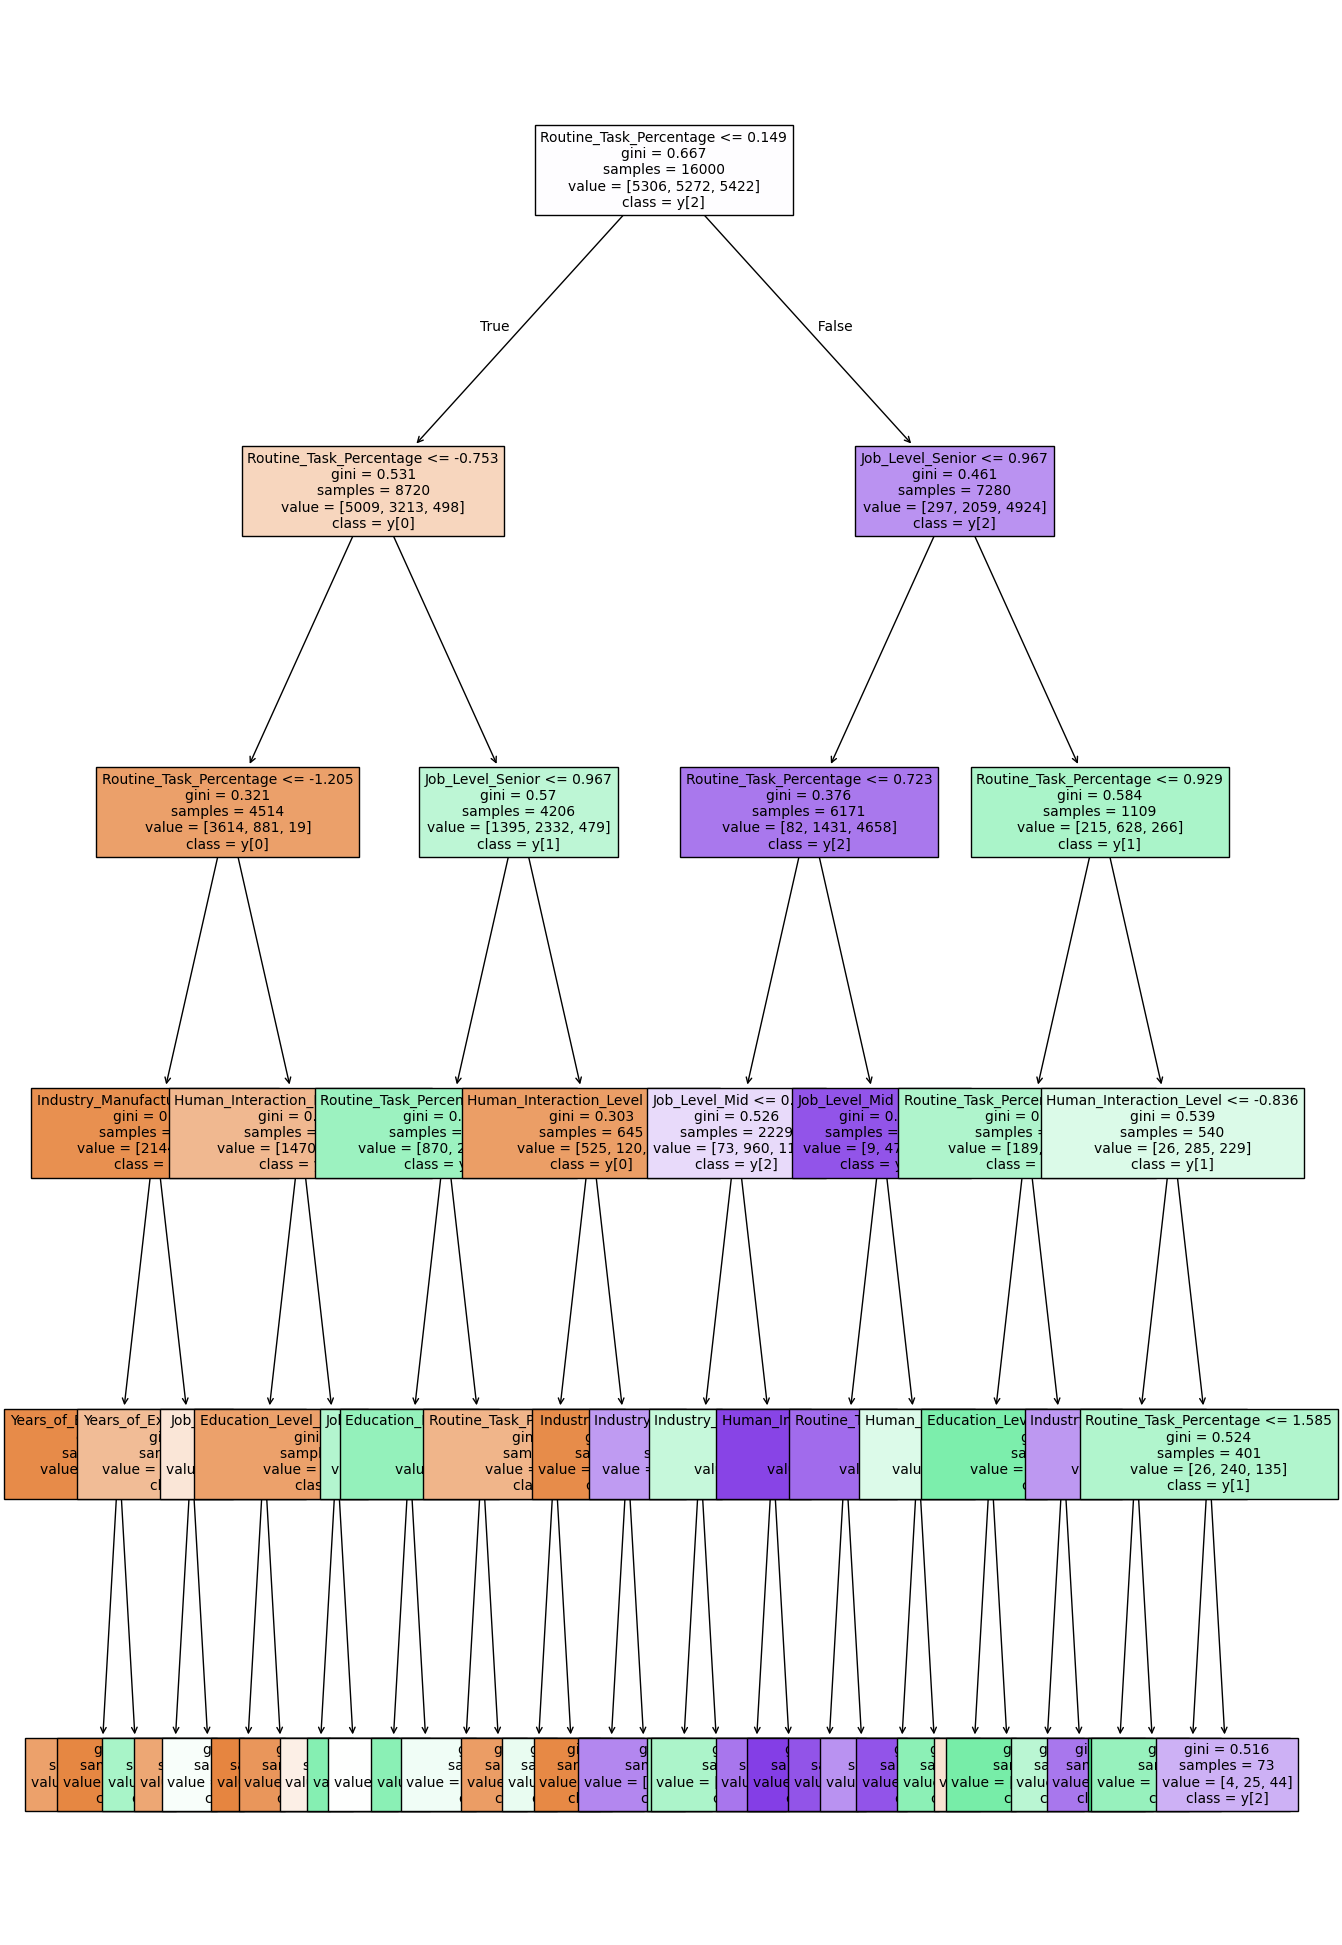

In [14]:
from sklearn import tree
plt.figure(figsize=(15,25))
tree.plot_tree(dt,filled=True,fontsize=10,feature_names=X.columns,class_names=True)
#plt.savefig('desion_tree.png',dpi=300,bbox_inches='tight')
plt.show()

                           Feature    Weight
2          Routine_Task_Percentage  0.764689
43                Job_Level_Senior  0.136368
42                   Job_Level_Mid  0.031481
3          Human_Interaction_Level  0.022293
7      Education_Level_High School  0.015226
14          Industry_Manufacturing  0.013186
11             Industry_Healthcare  0.010128
1              Years_of_Experience  0.006277
15                 Industry_Retail  0.000353
6                AI_Training_Hours  0.000000
5          AI_Usage_Hours_Per_Week  0.000000
4          Number_of_AI_Tools_Used  0.000000
8         Education_Level_Master's  0.000000
0                              Age  0.000000
13              Industry_Logistics  0.000000
12                     Industry_IT  0.000000
10                Industry_Finance  0.000000
9              Education_Level_PhD  0.000000
18                Job_Role_Auditor  0.000000
19           Job_Role_Data Analyst  0.000000
16                Industry_Telecom  0.000000
17        

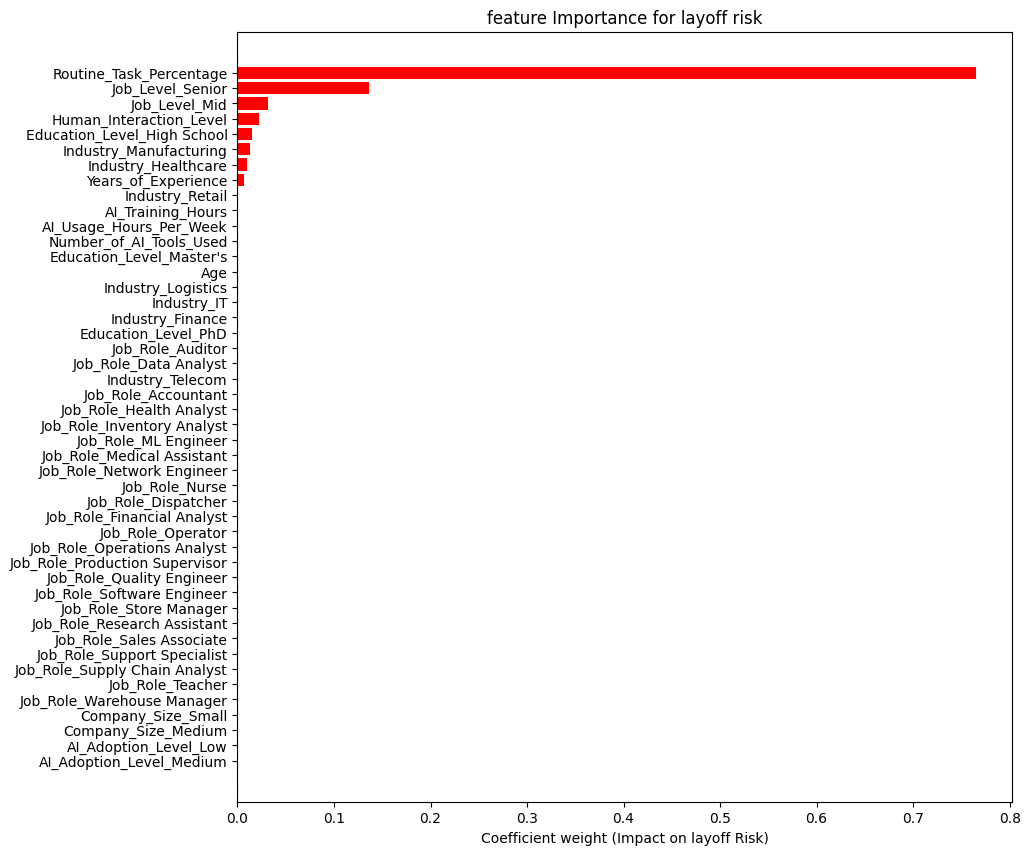

In [16]:
cofficients=dt.feature_importances_

feature_name=X.columns

importance_df=pd.DataFrame({'Feature':feature_name,'Weight':cofficients}).sort_values(by='Weight',ascending=False)
print(importance_df)

plt.figure(figsize=(10,10))
plt.barh(importance_df['Feature'],importance_df['Weight'],color='red')
plt.axvline(0, color='black',linestyle='--')
plt.xlabel('Coefficient weight (Impact on layoff Risk)')
plt.title('feature Importance for layoff risk')
plt.gca().invert_yaxis()
plt.show()

In [18]:
#here comes a major step in ml . hyperparameter turing : it is doing changes parameters to improve our model accuracy
# using grand search cv
from sklearn.model_selection import GridSearchCV

param_gram={'max_depth':[3,5,10,None],'min_samples_split':[2,5,10]} 
# n estimators is no of trees in the forest,max depth of tree,minimum sample to split a node 
dt_base=DecisionTreeClassifier(random_state=42)

grid_search=GridSearchCV(estimator=dt_base, param_grid=param_gram, cv=3, scoring='accuracy',n_jobs=-1)

In [19]:
print("Searching for the best  hyperparameter ...(this might take a few moments)")
grid_search.fit(x_train,y_train)
print("\nBest parameter Found:",grid_search.best_params_)

Searching for the best  hyperparameter ...(this might take a few moments)

Best parameter Found: {'max_depth': 10, 'min_samples_split': 10}


In [22]:
best_dt_model=grid_search.best_estimator_
grid_pred=best_dt_model.predict(x_test)

print("\n---------------tuned decision tree Performance--------------------")
print("new Accuracy:",accuracy_score(y_test,grid_pred))
print("new Classsinfication Report: \n",classification_report(y_test,grid_pred))


---------------tuned decision tree Performance--------------------
new Accuracy: 0.8075
new Classsinfication Report: 
               precision    recall  f1-score   support

           0       0.87      0.83      0.85      1296
           1       0.69      0.76      0.72      1329
           2       0.87      0.84      0.85      1375

    accuracy                           0.81      4000
   macro avg       0.81      0.81      0.81      4000
weighted avg       0.81      0.81      0.81      4000



C:\Users\nidhi\AppData\Local\Temp\ipykernel_14192\589243409.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance',y='Feature',data=importance_df.head(10),palette='viridis')


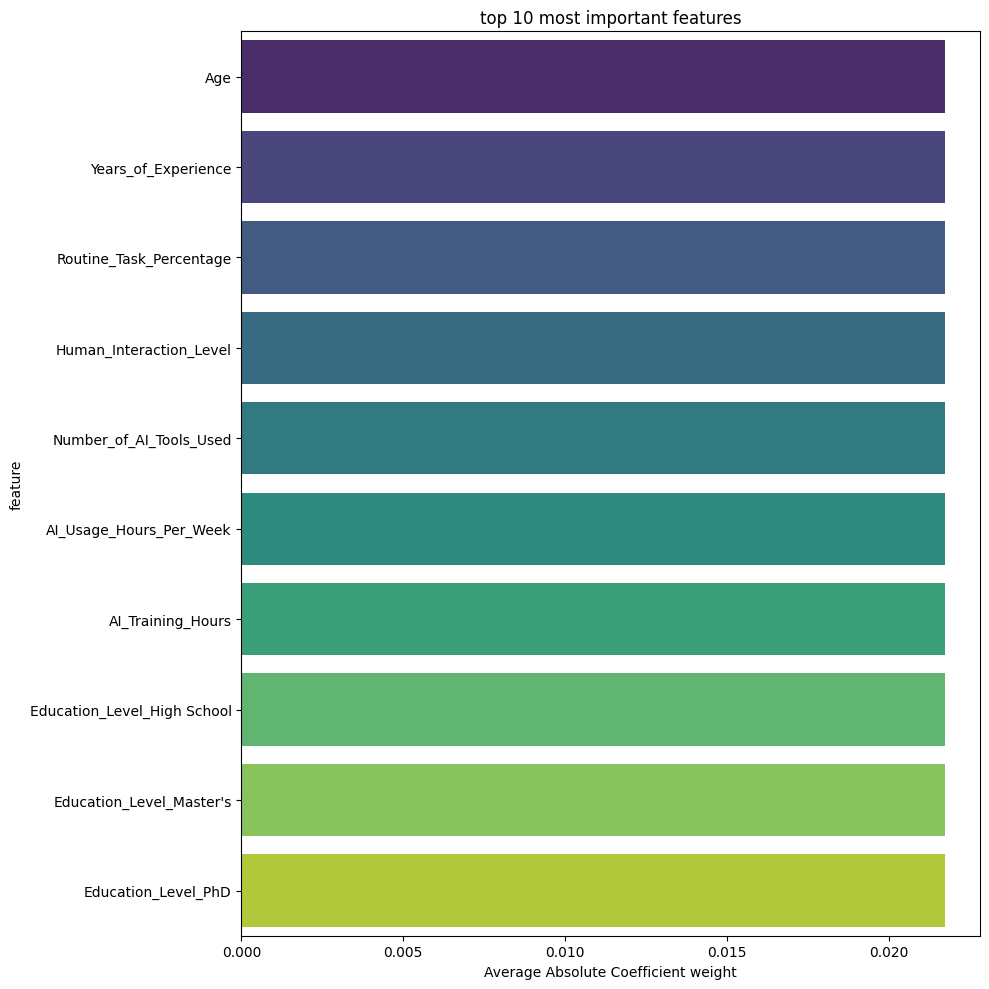

In [21]:
feature_name=X.columns if 'X' in locals() else df_encoded.drop(columns=['Layoff_Risk'],errors='ignore').columns

avg_importance=np.mean(np.abs(dt.feature_importances_),axis=0)

importance_df=pd.DataFrame({'Feature':feature_name,'Importance':avg_importance}).sort_values(by='Importance',ascending=False)

plt.figure(figsize=(10,10))
sns.barplot(x='Importance',y='Feature',data=importance_df.head(10),palette='viridis')
plt.title("top 10 most important features")
plt.xlabel('Average Absolute Coefficient weight')
plt.ylabel('feature')
plt.tight_layout()
plt.show()